# Praktikum 1.2: EDA Korelasi Gizi dengan Label Nutri-Score

Melanjutkan `1_scraping.ipynb`. Jalankan notebook tersebut lebih dulu agar `data/off_nutrition.csv` tersedia.

**Pertanyaan yang dijawab:** zat gizi apa yang paling menentukan sebuah produk mendapat label Nutri-Score `a` (terbaik) atau `e` (terburuk)?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULT_FILE = Path("data/off_nutrition.csv")

NUTRIENTS = [
    "energy-kcal_100g",
    "fat_100g",
    "saturated-fat_100g",
    "carbohydrates_100g",
    "sugars_100g",
    "fiber_100g",
    "proteins_100g",
    "salt_100g",
    "fruits-vegetables-nuts-estimate-from-ingredients_100g",
]

if not RESULT_FILE.exists():
    raise FileNotFoundError(f"{RESULT_FILE} belum ada, jalankan 1_scraping.ipynb dulu.")

df_mentah = pd.read_csv(RESULT_FILE, dtype={"code": str})
print("Ukuran:", df_mentah.shape)
df_mentah.head()

Ukuran: (1999, 15)


,code,product_name,brands,nutriscore_grade,nutriscore_score,nova_group,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g
0,6111035000430,Sidi Ali,سيدي علي,a,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00
1,6111242100992,Perly,Jaouda,a,0,3.0,97.0,3.0,0.0,9.4,9.4,0.0,8.0,0.00000,6.85
2,6111035000058,Eau minérale naturelle,sidi ali,a,0,1.0,0.0,0.0,NaN,0.0,NaN,NaN,0.0,0.00600,0.00
3,6111035002175,Sidi Ali,Sidi Ali,a,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
4,3274080005003,isabelle,Cristaline,a,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00275,0.00


## 1. Pembersihan data

Open Food Facts diisi sukarela oleh kontributor, jadi wajar ada nilai kosong, duplikat, dan angka mustahil (misalnya lemak 900 g per 100 g). Langkah pembersihan:

1. **duplikat:** satu produk (`code`) bisa muncul di lebih dari satu halaman
2. **tipe data:** semua kolom gizi dipaksa numerik, teks yang gagal jadi `NaN`
3. **rentang wajar:** massa per 100 g tidak mungkin negatif atau melebihi 100 g, dan energi dibatasi 900 kkal (lemak murni ≈ 900 kkal/100 g). Nilai di luar itu kemungkinan besar salah input, bukan outlier asli, jadi dijadikan `NaN` karena kolom lain di baris yang sama masih berguna.

In [2]:
df = df_mentah.drop_duplicates(subset="code").copy()

for kolom in NUTRIENTS + ["nutriscore_score", "nova_group"]:
    df[kolom] = pd.to_numeric(df[kolom], errors="coerce")

# Buang nilai tidak masuk akal
batas_atas = {kolom: 100.0 for kolom in NUTRIENTS}
batas_atas["energy-kcal_100g"] = 900.0

for kolom, atas in batas_atas.items():
    df.loc[~df[kolom].between(0, atas), kolom] = np.nan

# Label adalah variabel target
df = df.dropna(subset=["nutriscore_grade"])

# Nutri-Score bersifat ordinal
GRADES = ["a", "b", "c", "d", "e"]
df["nutriscore_grade"] = pd.Categorical(df["nutriscore_grade"], categories=GRADES, ordered=True)
df["grade_ordinal"] = df["nutriscore_grade"].cat.codes + 1  # a=1 s.d. e=5, makin besar makin buruk

print("Setelah dibersihkan:", df.shape)
print("\nSebaran label:")
print(df["nutriscore_grade"].value_counts().sort_index())
print("\nKelengkapan kolom gizi:")
print(df[NUTRIENTS].notna().mean().sort_values(ascending=False).round(3))

Setelah dibersihkan: (1999, 16)

Sebaran label:
nutriscore_grade
a    400
b    400
c    400
d    400
e    399
Name: count, dtype: int64

Kelengkapan kolom gizi:
salt_100g                                                0.958
energy-kcal_100g                                         0.950
proteins_100g                                            0.949
fat_100g                                                 0.949
sugars_100g                                              0.948
saturated-fat_100g                                       0.948
carbohydrates_100g                                       0.945
fruits-vegetables-nuts-estimate-from-ingredients_100g    0.879
fiber_100g                                               0.733
dtype: float64


## 2. Statistik deskriptif

Pada jarak antara median dan rata-rata pada kolom seperti `sugars_100g`: kalau rata-rata jauh di atas median, sebarannya miring ke kanan (banyak produk berkadar rendah, sedikit produk berkadar sangat tinggi). Ini alasan utama memilih korelasi berbasis peringkat
di bagian berikutnya.

In [3]:
df[NUTRIENTS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
energy-kcal_100g,1899.0,300.26,209.49,0.0,98.51,289.00,456.00,900.0
fat_100g,1897.0,16.22,20.21,0.0,1.90,8.30,23.00,100.0
saturated-fat_100g,1895.0,5.45,8.38,0.0,0.40,1.70,7.20,60.0
carbohydrates_100g,1890.0,29.96,27.69,0.0,4.50,18.18,57.50,100.0
sugars_100g,1896.0,11.44,16.28,0.0,1.10,4.40,15.00,100.0
fiber_100g,1465.0,4.18,4.69,0.0,0.50,3.00,6.50,66.0
proteins_100g,1898.0,7.42,6.62,0.0,2.70,6.70,9.80,75.0
salt_100g,1916.0,0.66,1.61,0.0,0.03,0.30,0.95,44.6
fruits-vegetables-nuts-estimate-from-ingredients_100g,1757.0,13.73,26.22,0.0,0.00,0.00,13.00,100.0


## 3. Korelasi gizi dengan label

`grade_ordinal` adalah peringkat (a=1 s.d. e=5), bukan besaran yang jaraknya setara, sehingga korelasi yang tepat adalah **Spearman** (berbasis peringkat), bukan Pearson. Spearman juga tahan terhadap sebaran gizi yang miring seperti terlihat di atas.

Tanda korelasi dibaca begini:

- **positif** → makin tinggi kandungannya, makin buruk labelnya (bergerak ke `e`)
- **negatif** → makin tinggi kandungannya, makin baik labelnya (bergerak ke `a`)

In [4]:
corr = (
    df[NUTRIENTS + ["grade_ordinal"]]
    .corr(method="spearman", numeric_only=True)["grade_ordinal"]
    .drop("grade_ordinal")
    .sort_values()
)

summary = pd.DataFrame({
    "spearman_vs_grade": corr.round(3),
    "n_data": df[corr.index].notna().sum(),
})
summary["arah"] = np.where(summary["spearman_vs_grade"] > 0, "memperburuk label", "memperbaiki label")
summary

,spearman_vs_grade,n_data,arah
proteins_100g,-0.139,1898,memperbaiki label
fiber_100g,-0.122,1465,memperbaiki label
fruits-vegetables-nuts-estimate-from-ingredients_100g,-0.047,1757,memperbaiki label
salt_100g,0.173,1916,memperburuk label
carbohydrates_100g,0.233,1890,memperburuk label
fat_100g,0.394,1897,memperburuk label
energy-kcal_100g,0.397,1899,memperburuk label
saturated-fat_100g,0.473,1895,memperburuk label
sugars_100g,0.502,1896,memperburuk label


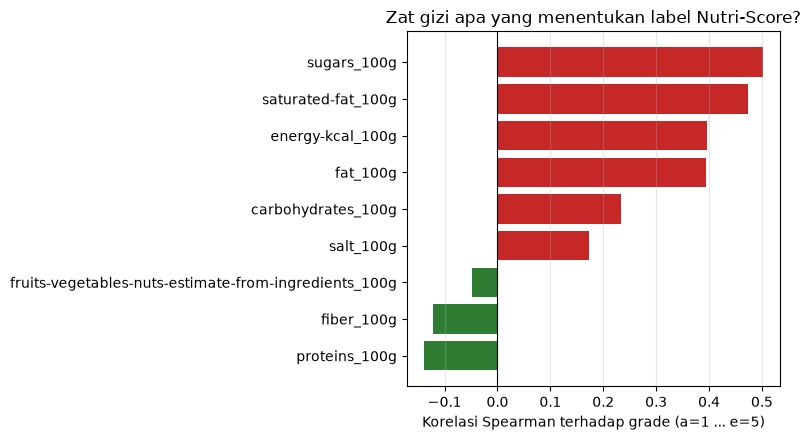

In [5]:
warna = ["#2e7d32" if nilai < 0 else "#c62828" for nilai in corr]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(corr.index, corr.values, color=warna)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Korelasi Spearman terhadap grade (a=1 ... e=5)")
ax.set_title("Zat gizi apa yang menentukan label Nutri-Score?")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Bentuk hubungannya

Korelasi meringkas arah hubungan menjadi satu angka. Tabel dan boxplot berikut menunjukkan
bentuknya: apakah benar naik monoton dari `a` ke `e`, atau justru mendatar di grade tengah.
Median dipakai, bukan rata-rata, karena alasan kemiringan sebaran tadi.

In [6]:
m = df.groupby("nutriscore_grade", observed=True)[NUTRIENTS].median().round(2)
m.insert(0, "jumlah_produk", df["nutriscore_grade"].value_counts().sort_index())
m

,jumlah_produk,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,fruits-vegetables-nuts-estimate-from-ingredients_100g
nutriscore_grade,,,,,,,,,,
a,400,139.0,2.8,0.5,8.00,2.60,4.4,9.70,0.10,0.00
b,400,155.5,3.2,1.0,8.17,2.30,2.8,5.40,0.18,2.50
c,400,283.0,8.0,1.8,16.75,4.50,3.9,7.00,0.49,1.75
d,400,345.0,19.0,4.8,24.00,6.50,3.0,6.95,0.75,0.00
e,399,484.0,24.0,9.0,50.86,28.65,2.5,6.00,0.26,0.00


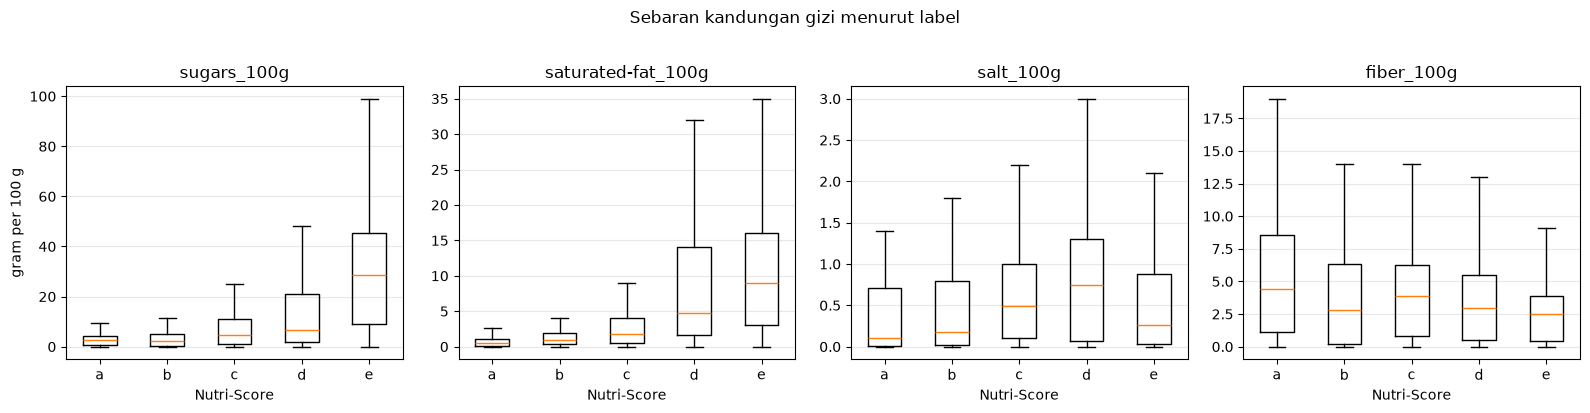

In [7]:
highlights = ["sugars_100g", "saturated-fat_100g", "salt_100g", "fiber_100g"]

fig, axes = plt.subplots(1, len(highlights), figsize=(16, 4))
for ax, col in zip(axes, highlights):
    data = [df.loc[df["nutriscore_grade"] == g, col].dropna() for g in GRADES]
    ax.boxplot(data, tick_labels=GRADES, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("Nutri-Score")
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("gram per 100 g")
fig.suptitle("Sebaran kandungan gizi menurut label", y=1.02)
fig.tight_layout()
plt.show()

## 5. Korelasi antar zat gizi

Kolom-kolom gizi juga saling berkorelasi (misalnya lemak dengan lemak jenuh, atau energi
dengan hampir semuanya). Ini penting diketahui sebelum dipakai sebagai fitur model: fitur
yang sangat berkorelasi membawa informasi yang sama, sehingga salah satunya bisa dibuang.

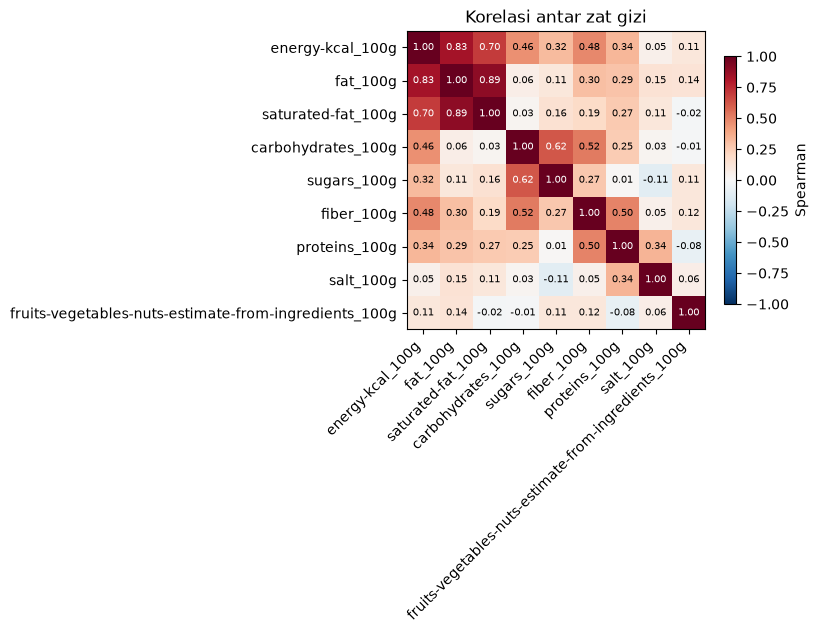

In [8]:
matrix = df[NUTRIENTS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6.5))
img = ax.imshow(matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(matrix)), matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matrix)), matrix.index)

for i in range(len(matrix)):
    for j in range(len(matrix)):
        nilai = matrix.iat[i, j]
        ax.text(j, i, f"{nilai:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(nilai) > 0.55 else "black")

fig.colorbar(img, ax=ax, shrink=0.8, label="Spearman")
ax.set_title("Korelasi antar zat gizi")
fig.tight_layout()
plt.show()

## 6. Kesimpulan

In [9]:
terkuat = corr.abs().sort_values(ascending=False)

print("Zat gizi paling menentukan label (|Spearman| terbesar):")
for col in terkuat.index[:4]:
    rate = corr[col]
    arah = "grade memburuk" if rate > 0 else "grade membaik"
    print(f"  {col:<50} {rate:+.3f}  → makin tinggi, {arah}")

# DataFrame.corr memakai peringkat internal, jadi tidak membutuhkan scipy.
konsistensi = df[["grade_ordinal", "nutriscore_score"]].corr(method="spearman").iat[0, 1]
print(f"\nKorelasi grade dengan nutriscore_score bawaan: {konsistensi:+.3f}")
print("(mendekati +1 karena grade memang diturunkan dari skor tersebut — bukan temuan baru,")
print(" melainkan pemeriksaan bahwa data terunduh konsisten.)")

Zat gizi paling menentukan label (|Spearman| terbesar):
  sugars_100g                                        +0.502  → makin tinggi, grade memburuk
  saturated-fat_100g                                 +0.473  → makin tinggi, grade memburuk
  energy-kcal_100g                                   +0.397  → makin tinggi, grade memburuk
  fat_100g                                           +0.394  → makin tinggi, grade memburuk

Korelasi grade dengan nutriscore_score bawaan: +0.955
(mendekati +1 karena grade memang diturunkan dari skor tersebut — bukan temuan baru,
 melainkan pemeriksaan bahwa data terunduh konsisten.)


**Hasil yang didapatkan:** Lemak jenuh dan gula merupakan penentu terkuat label Nutri-Score, diikuti lemak total dan energi—arahnya positif, artinya makin tinggi kandungannya makin buruk labelnya.

Sebaliknya, protein dan serat berkorelasi negatif: keduanya memperbaiki label. Arah ini persis sesuai rumus resmi Nutri-Score, yang memberi poin penalti untuk energi, gula, lemak jenuh, dan garam, lalu poin pengurang untuk serat, protein, serta buah/sayur/kacang.

**Kenapa nilainya tidak mendekati ±1?** Nutri-Score tidak menjumlahkan nutrisi secara linear, melainkan memetakan tiap nutrisi ke poin diskret lewat tabel ambang, lalu menjumlahkan poin-poin itu. Akibatnya tidak ada satu nutrisi pun yang bisa memprediksi label sendirian (label adalah hasil gabungan). Selain itu ambang poinnya berbeda untuk kategori khusus (minuman, lemak tambahan, keju), sementara sampel di sini mencampur semua kategori.

**Catatan mutu dataset:** `fiber_100g` hanya terisi sekitar 73%, paling rendah di antara semua kolom. Korelasinya dihitung dari sebagian data saja, jadi angkanya lebih lemah daripada kolom lain yang terisi di atas 94%.

**Batasan sampel:** Sampel dibuat berimbang per grade (~400 produk tiap label), bukan acak dari populasi. Ini tepat untuk membandingkan antar grade, tetapi proporsi tiap grade di sini **tidak** mencerminkan komposisi asli basis data Open Food Facts.